In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (3634348, 18)


In [4]:
# Filter to only include measurements at 3-hour intervals (0, 3, 6, 9, 12, 15, 18, 21)
CV_rows_3hr = CV_rows[CV_rows['hour'].isin([0, 3, 6, 9, 12, 15, 18, 21])]

# Define continuous variables to average
continuous_vars = ['HourlyDewPointTemperature', 'HourlyDryBulbTemperature',
                    'HourlyPrecipitation', 'HourlyVisibility',
                    'HourlyWindDirection', 'HourlyWindSpeed']

# Group by station and date, then average the continuous variables
CV_daily = CV_rows_3hr.groupby(['STATION_ID', 'LATITUDE', 'LONGITUDE', 'year', 'month', 'day', 'STATION'])[continuous_vars].mean().reset_index()

print(CV_daily)

         STATION_ID  LATITUDE  LONGITUDE  year  month  day  \
0       USW00023110  36.33333 -119.95000  1961     11    1   
1       USW00023110  36.33333 -119.95000  1961     11    2   
2       USW00023110  36.33333 -119.95000  1961     11    3   
3       USW00023110  36.33333 -119.95000  1961     11    4   
4       USW00023110  36.33333 -119.95000  1961     11    5   
...             ...       ...        ...   ...    ...  ...   
130245  USW00093225  38.69556 -121.58972  2026      3   27   
130246  USW00093225  38.69556 -121.58972  2026      3   28   
130247  USW00093225  38.69556 -121.58972  2026      3   29   
130248  USW00093225  38.69556 -121.58972  2026      3   30   
130249  USW00093225  38.69556 -121.58972  2026      3   31   

                           STATION  HourlyDewPointTemperature  \
0               LEMOORE REEVES NAS                    -0.0625   
1               LEMOORE REEVES NAS                     4.7875   
2               LEMOORE REEVES NAS                     1.800

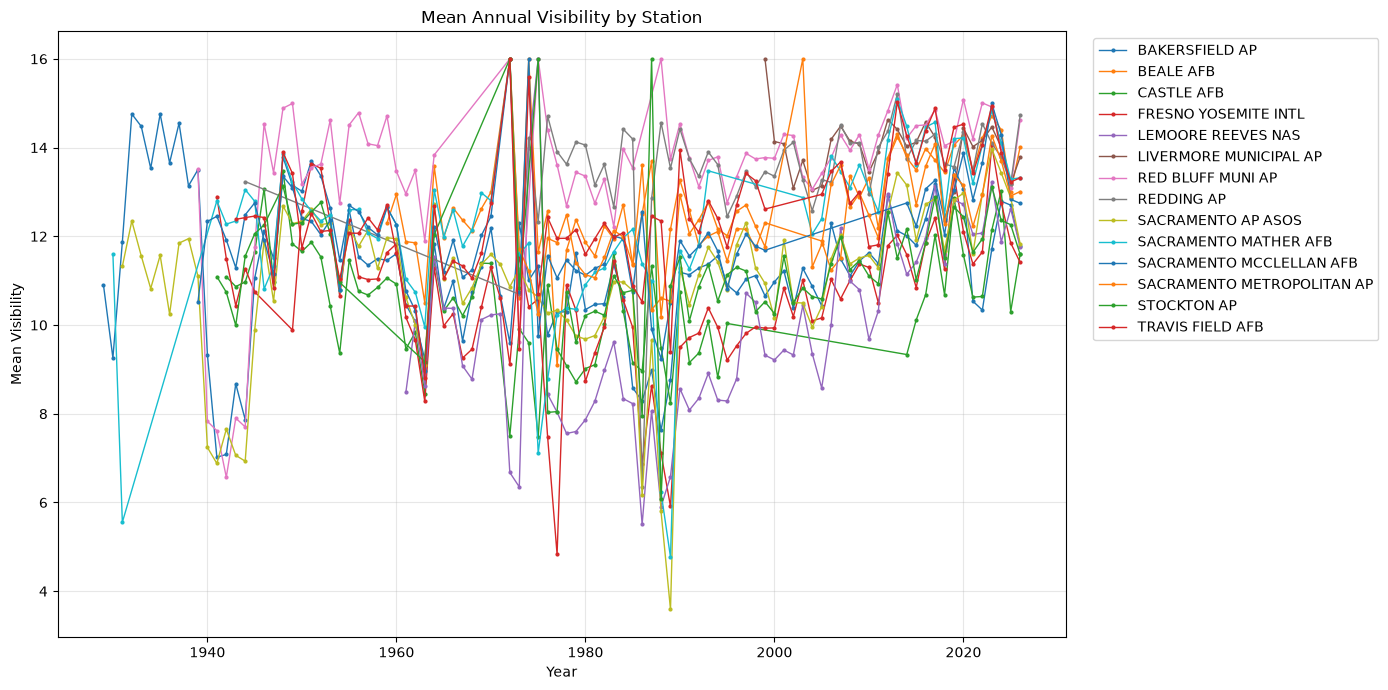

In [5]:
# Calculate mean annual visibility for each station
visibility_by_station_year = (
    CV_daily
    .groupby(['STATION_ID', 'STATION', 'year'], as_index=False)['HourlyVisibility']
    .mean()
)

# Plot annual visibility by station
fig, ax = plt.subplots(figsize=(14, 7))

for station, data in visibility_by_station_year.groupby('STATION'):
    ax.plot(
        data['year'],
        data['HourlyVisibility'],
        marker='o',
        markersize=2,
        linewidth=1,
        label=station
    )

ax.set_title('Mean Annual Visibility by Station')
ax.set_xlabel('Year')
ax.set_ylabel('Mean Visibility')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()